In [4]:
from data_analysis import combine_pipeline_csvs_to_lexical_master, clean_variation_and_subreddit_columns
import pandas as pd
import matplotlib.pyplot as plt
from visualization import *

# Combine Files

In [5]:
combine_pipeline_csvs_to_lexical_master(convokit_root='/Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit')

[1/9] Reading /Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/Age-Variation/subreddit-college_lexical_df.csv
[2/9] Reading /Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/Age-Variation/subreddit-parent_lexical_df.csv
[3/9] Reading /Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/Age-Variation/subreddit-teenagers_lexical_df.csv
[4/9] Reading /Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/Culture-Variation/subreddit-books_lexical_df.csv
[5/9] Reading /Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/Culture-Variation/subreddit-movies_lexical_df.csv
[6/9] Reading /Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/Culture-Variation/subreddit-religion_lexical_df.csv
[7/9] Reading /Users/nickvick

RuntimeError: Failed to read CSV: /Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/Topic-Variation/subreddit-worldnews_lexical_df.csv
If this is in a cloud-synced folder, ensure the file is downloaded locally or rerun with skip_read_errors=True.

In [2]:
df = pd.read_csv('/Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/Convokit/lexical_master.csv')
print(df.head())

             timestamp utterance_id       speaker_id  \
0  2012-01-01 10:13:05        nylo3   throwaway19234   
1  2012-01-04 17:27:59        o332f     AmpleDeficit   
2  2012-01-03 20:29:10        o1uwt   Sliverfish7654   
3  2012-01-03 19:59:41        o1to7  doesntmatter108   
4  2012-01-04 23:05:24        o3hu3        MyRoomate   

                                            raw_text  \
0  Looking for good grab and go snacks, microwave...   
1  In a nutshell, I'm a community college student...   
2  Does anybody know any grants or scholarships t...   
3  I am just starting classes to get my AAS. I FI...   
4  I'm thinking about becoming a lawyer. I don't ...   

   num_utterances_by_speaker  post_depth  score  num_direct_replies  \
0                          1           0      1                   6   
1                          3           0      6                   4   
2                          1           0      0                   1   
3                          5           0  

In [3]:
df = clean_variation_and_subreddit_columns(df)
print(df.head())

             timestamp utterance_id       speaker_id  \
0  2012-01-01 10:13:05        nylo3   throwaway19234   
1  2012-01-04 17:27:59        o332f     AmpleDeficit   
2  2012-01-03 20:29:10        o1uwt   Sliverfish7654   
3  2012-01-03 19:59:41        o1to7  doesntmatter108   
4  2012-01-04 23:05:24        o3hu3        MyRoomate   

                                            raw_text  \
0  Looking for good grab and go snacks, microwave...   
1  In a nutshell, I'm a community college student...   
2  Does anybody know any grants or scholarships t...   
3  I am just starting classes to get my AAS. I FI...   
4  I'm thinking about becoming a lawyer. I don't ...   

   num_utterances_by_speaker  post_depth  score  num_direct_replies  \
0                          1           0      1                   6   
1                          3           0      6                   4   
2                          1           0      0                   1   
3                          5           0  

# Explore Data

/var/folders/dj/6y_wgvgs5m59w08whyk9sjp80000gn/T/ipykernel_17580/2878660390.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = time_df.resample('M').size().rename('post_count')


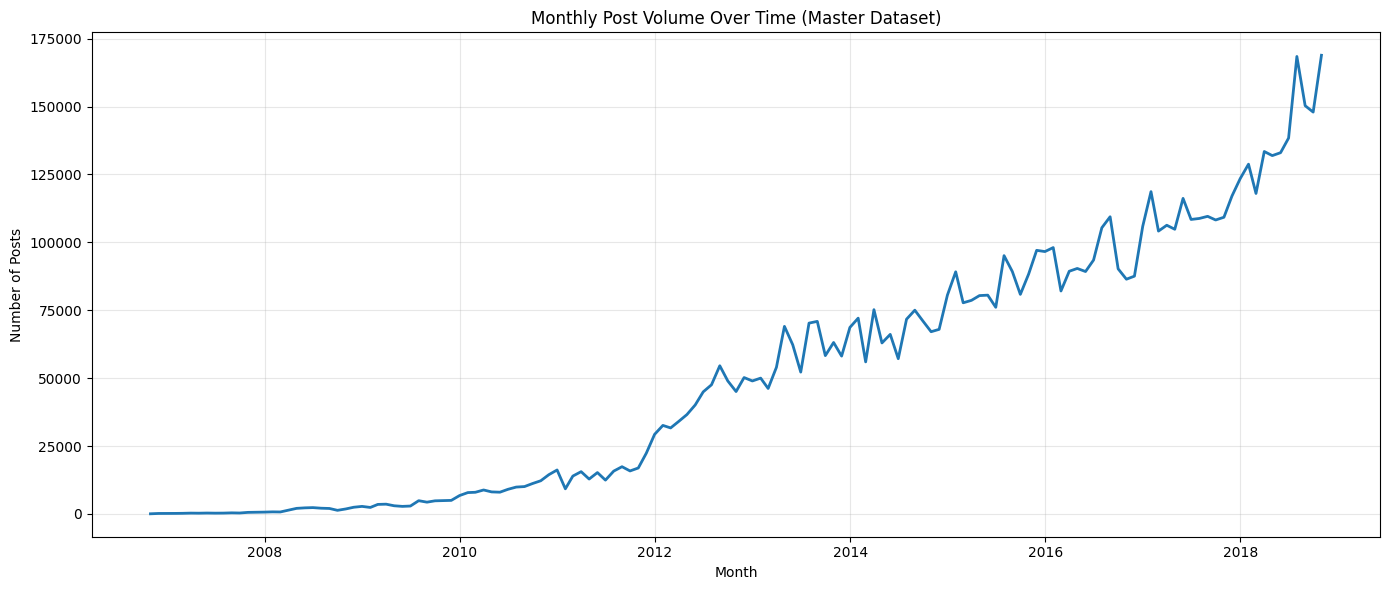

In [4]:
# Support either a timestamp column or a datetime index
if 'timestamp' in df.columns:
    time_df = df.copy()
    time_df['timestamp'] = pd.to_datetime(time_df['timestamp'], errors='coerce')
    time_df = time_df.dropna(subset=['timestamp']).set_index('timestamp')
elif isinstance(df.index, pd.DatetimeIndex):
    time_df = df.copy()
else:
    raise ValueError("df must have a 'timestamp' column or a DatetimeIndex")

monthly_counts = time_df.resample('M').size().rename('post_count')

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_counts.index, monthly_counts.values, color='tab:blue', linewidth=2)
ax.set_title('Monthly Post Volume Over Time (Master Dataset)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Posts')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Visualize Temporal Trends

/Users/nickvick/Desktop/Thesis/ORFE-Thesis/src/visualization.py:227: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  resampled  = ts_df[col].resample(resample_freq).agg(['mean', 'std', 'count'])


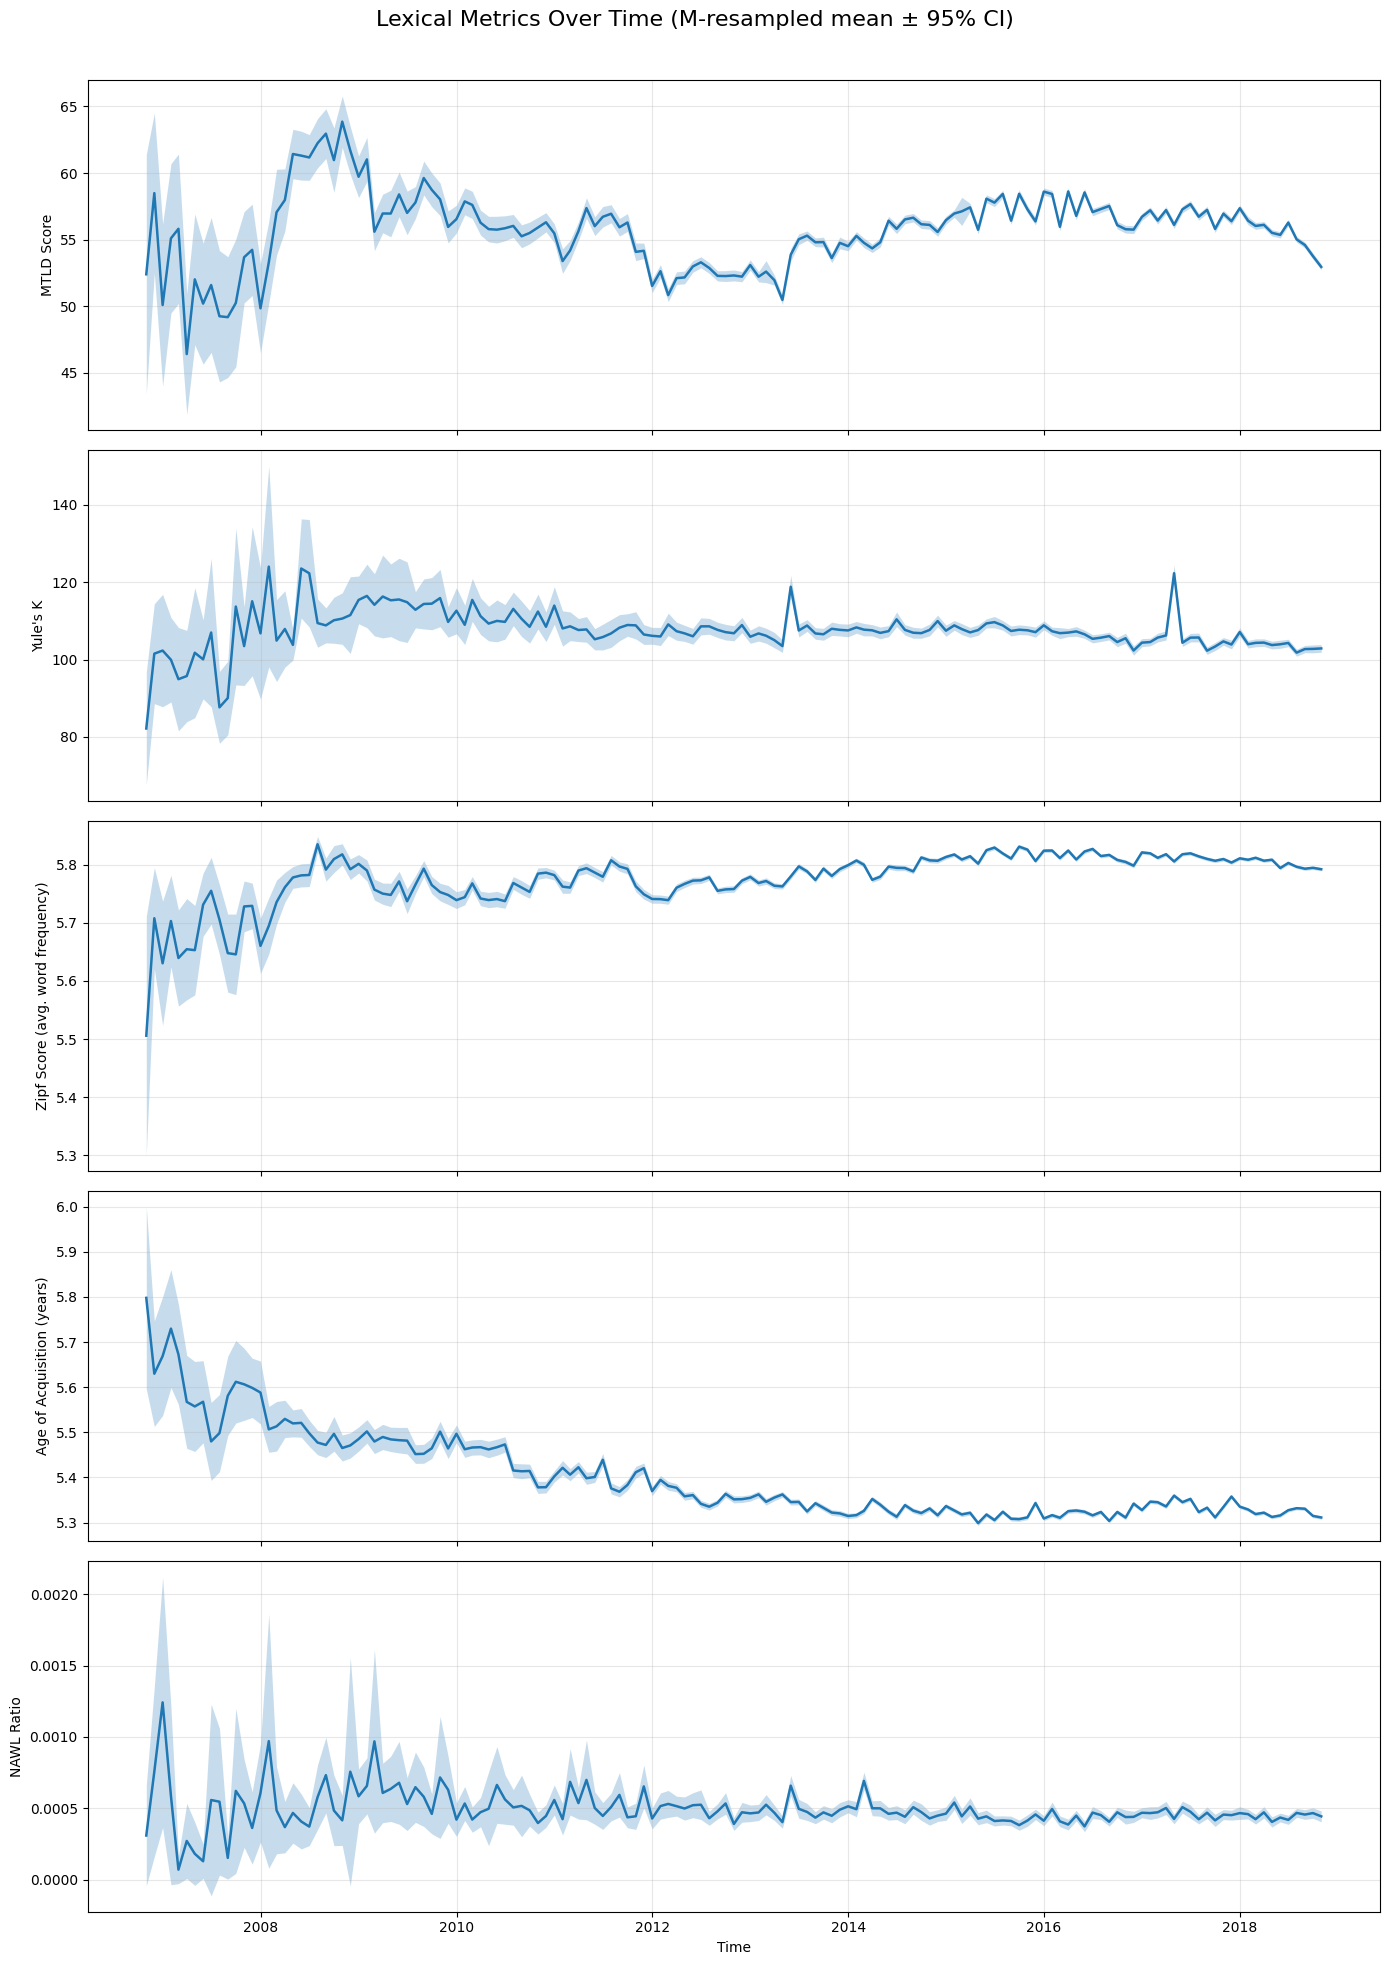

In [5]:
plot_lexical_metrics(df, resample_freq='M')

# Linear Regression

## Predicting AoA

In [5]:
from data_analysis import run_log_linear_regression

result = run_log_linear_regression(
    df,
    predictors=[
        "num_utterances_by_speaker",
        "post_depth",
        "score",
        "num_direct_replies",
        "subreddit",
        "timestamp",  # converted internally to year
    ],
    target="aoa_score",
    test_size=0.2,
    random_state=42,
)

print(f"Train rows: {result['train_rows']:,}")
print(f"Test rows:  {result['test_rows']:,}")
print(f"RMSE: {result['rmse']:.4f}")
print(f"MAE:  {result['mae']:.4f}")
print(f"R^2:  {result['r2']:.4f}")

print("\nTop coefficients by absolute value (AoA Model):")
print(result["coef_df"].head(20))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


Train rows: 5,807,796
Test rows:  1,451,950
RMSE: 0.7426
MAE:  0.4623
R^2:  0.0493

Top coefficients by absolute value (AoA Model):
                               feature  coefficient
9         cat__subreddit_relationships    -0.259217
11              cat__subreddit_science     0.238012
13            cat__subreddit_worldnews     0.196429
8                cat__subreddit_parent    -0.189588
10             cat__subreddit_religion     0.160579
12            cat__subreddit_teenagers    -0.145841
6               cat__subreddit_college     0.061241
7                cat__subreddit_movies    -0.031692
5                 cat__subreddit_books    -0.029922
3          num__log_num_direct_replies    -0.025145
0   num__log_num_utterances_by_speaker     0.016543
2                       num__log_score     0.007770
4                            num__year    -0.000386
1                      num__post_depth     0.000154


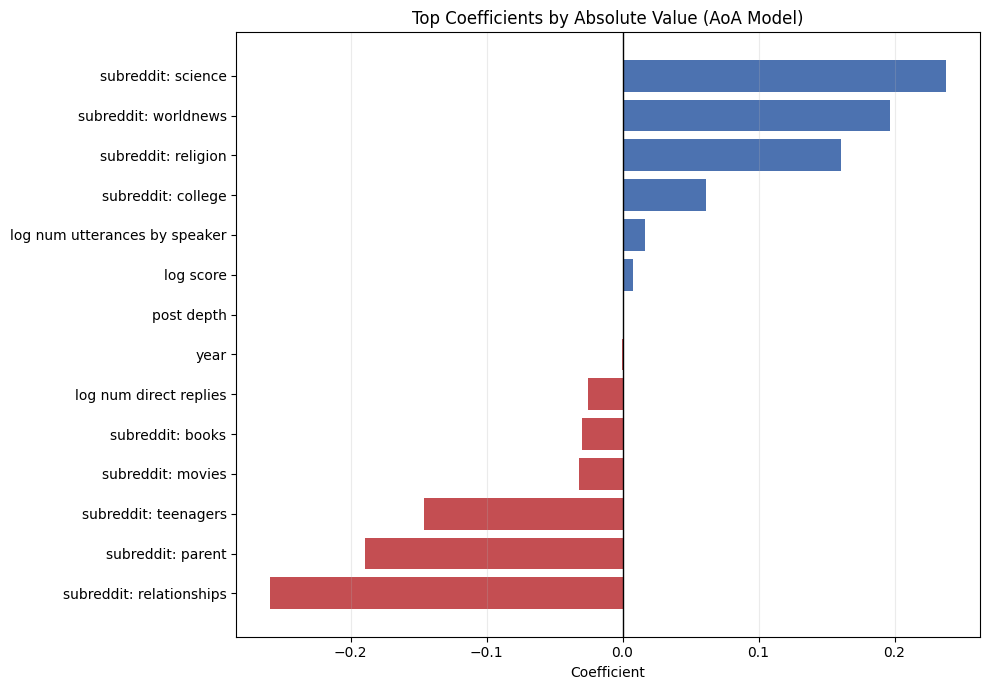

In [7]:
# Use the returned coefficient table
plot_df = result["coef_df"].copy()

# Prettier labels
plot_df["label"] = (
    plot_df["feature"]
    .str.replace("cat__subreddit_", "subreddit: ", regex=False)
    .str.replace("num__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

top_n = 20
top = plot_df.head(top_n).copy().sort_values("coefficient")

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#c44e52" if v < 0 else "#4c72b0" for v in top["coefficient"]]

ax.barh(top["label"], top["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title(f"Top Coefficients by Absolute Value (AoA Model)")
ax.set_xlabel("Coefficient")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()


## Predicting MTLD

In [8]:
from data_analysis import run_log_linear_regression

result = run_log_linear_regression(
    df,
    predictors=[
        "num_utterances_by_speaker",
        "post_depth",
        "score",
        "num_direct_replies",
        "subreddit",
        "timestamp",  # converted internally to year
    ],
    target="mtld_score",
    test_size=0.2,
    random_state=42,
)

print(f"Train rows: {result['train_rows']:,}")
print(f"Test rows:  {result['test_rows']:,}")
print(f"RMSE: {result['rmse']:.4f}")
print(f"MAE:  {result['mae']:.4f}")
print(f"R^2:  {result['r2']:.4f}")

print("\nTop coefficients by absolute value (MTLD Model):")
print(result["coef_df"].head(20))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


Train rows: 5,897,264
Test rows:  1,474,317
RMSE: 43.9153
MAE:  30.9600
R^2:  0.1109

Top coefficients by absolute value (MTLD Model):
                               feature  coefficient
12            cat__subreddit_teenagers   -15.880194
0   num__log_num_utterances_by_speaker    12.221710
8                cat__subreddit_parent     8.368810
7                cat__subreddit_movies    -7.974281
9         cat__subreddit_relationships     7.198139
6               cat__subreddit_college     6.623503
3          num__log_num_direct_replies     5.294413
13            cat__subreddit_worldnews    -3.653836
5                 cat__subreddit_books     2.370430
11              cat__subreddit_science     2.081768
10             cat__subreddit_religion     0.865660
2                       num__log_score    -0.473033
4                            num__year     0.299724
1                      num__post_depth     0.008037


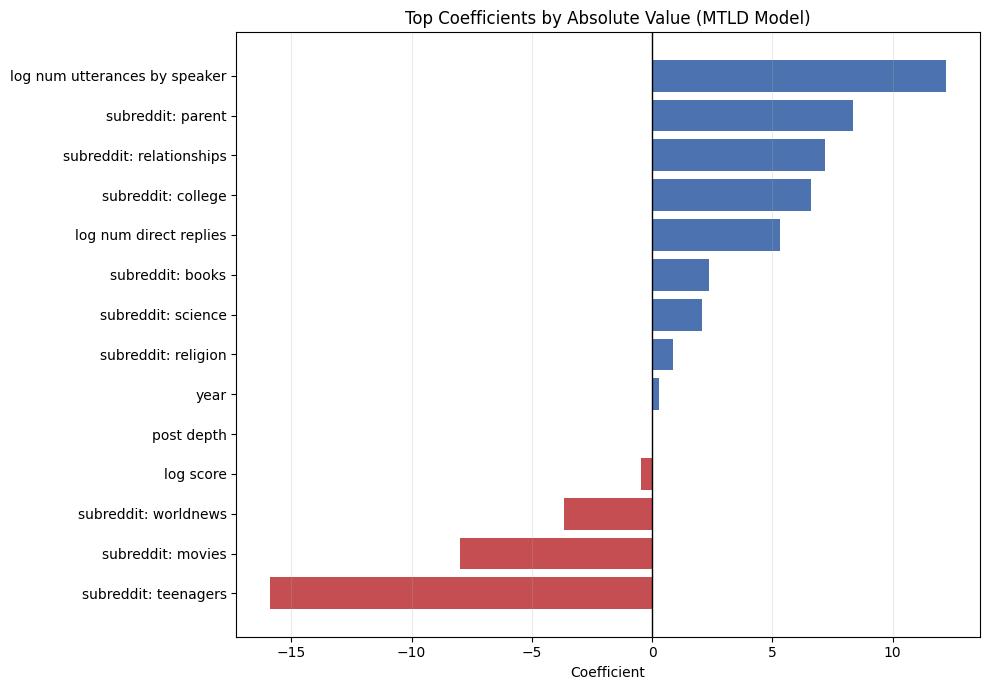

In [9]:
import matplotlib.pyplot as plt

# Use the returned coefficient table
plot_df = result["coef_df"].copy()

# Prettier labels
plot_df["label"] = (
    plot_df["feature"]
    .str.replace("cat__subreddit_", "subreddit: ", regex=False)
    .str.replace("num__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

top_n = 20
top = plot_df.head(top_n).copy().sort_values("coefficient")

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#c44e52" if v < 0 else "#4c72b0" for v in top["coefficient"]]

ax.barh(top["label"], top["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title(f"Top Coefficients by Absolute Value (MTLD Model)")
ax.set_xlabel("Coefficient")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

## Predicting Zipf Score

In [10]:
result = run_log_linear_regression(
    df,
    predictors=[
        "num_utterances_by_speaker",
        "post_depth",
        "score",
        "num_direct_replies",
        "subreddit",
        "timestamp",  # converted internally to year
    ],
    target="zipf_score",
    test_size=0.2,
    random_state=42,
)

print(f"Train rows: {result['train_rows']:,}")
print(f"Test rows:  {result['test_rows']:,}")
print(f"RMSE: {result['rmse']:.4f}")
print(f"MAE:  {result['mae']:.4f}")
print(f"R^2:  {result['r2']:.4f}")

print("\nTop coefficients by absolute value (Zipf Model):")
print(result["coef_df"].head(20))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


Train rows: 5,873,976
Test rows:  1,468,495
RMSE: 0.5407
MAE:  0.2951
R^2:  0.0517

Top coefficients by absolute value (Zipf Model):
                               feature  coefficient
9         cat__subreddit_relationships     0.181362
12            cat__subreddit_teenagers    -0.143675
7                cat__subreddit_movies    -0.105317
6               cat__subreddit_college     0.105049
13            cat__subreddit_worldnews    -0.076420
8                cat__subreddit_parent     0.074567
0   num__log_num_utterances_by_speaker     0.063794
3          num__log_num_direct_replies     0.049060
11              cat__subreddit_science    -0.021478
5                 cat__subreddit_books    -0.016012
2                       num__log_score    -0.007632
4                            num__year     0.004643
10             cat__subreddit_religion     0.001924
1                      num__post_depth     0.000149


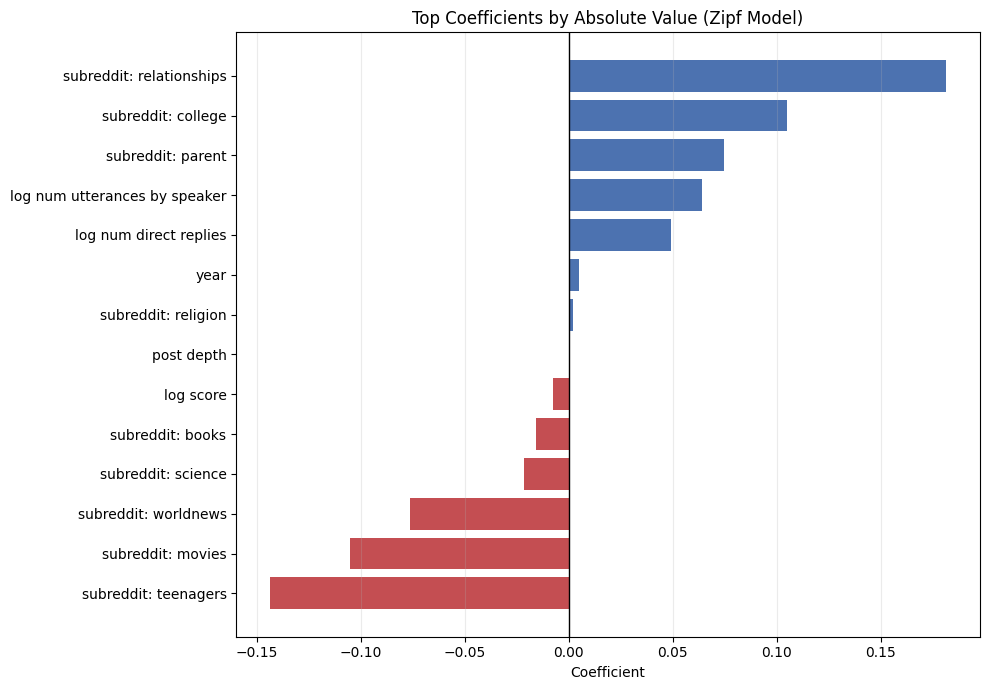

In [11]:
import matplotlib.pyplot as plt

# Use the returned coefficient table
plot_df = result["coef_df"].copy()

# Prettier labels
plot_df["label"] = (
    plot_df["feature"]
    .str.replace("cat__subreddit_", "subreddit: ", regex=False)
    .str.replace("num__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

top_n = 20
top = plot_df.head(top_n).copy().sort_values("coefficient")

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#c44e52" if v < 0 else "#4c72b0" for v in top["coefficient"]]

ax.barh(top["label"], top["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title(f"Top Coefficients by Absolute Value (Zipf Model)")
ax.set_xlabel("Coefficient")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

## Predicting MATTR

In [ ]:
result = run_log_linear_regression(
    df,
    predictors=[
        "num_utterances_by_speaker",
        "post_depth",
        "score",
        "num_direct_replies",
        "subreddit",
        "timestamp",  # converted internally to year
    ],
    target="mattr_score",
    test_size=0.2,
    random_state=42,
)

print(f"Train rows: {result['train_rows']:,}")
print(f"Test rows:  {result['test_rows']:,}")
print(f"RMSE: {result['rmse']:.4f}")
print(f"MAE:  {result['mae']:.4f}")
print(f"R^2:  {result['r2']:.4f}")

print("\nTop coefficients by absolute value:")
print(result["coef_df"].head(20))

In [ ]:
import matplotlib.pyplot as plt

# Use the returned coefficient table
plot_df = result["coef_df"].copy()

# Prettier labels
plot_df["label"] = (
    plot_df["feature"]
    .str.replace("cat__subreddit_", "subreddit: ", regex=False)
    .str.replace("num__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

top_n = 20
top = plot_df.head(top_n).copy().sort_values("coefficient")

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#c44e52" if v < 0 else "#4c72b0" for v in top["coefficient"]]

ax.barh(top["label"], top["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title(f"Top Coefficients by Absolute Value")
ax.set_xlabel("Coefficient")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

# Random Forest Regression


In [18]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Build modeling dataframe (same predictors as linear model + year)
rf_target = 'aoa_score'
rf_features = ['num_utterances_by_speaker', 'post_depth', 'score', 'num_direct_replies', 'subreddit', 'timestamp']
rf_df = df[[rf_target] + rf_features].copy()

rf_df['timestamp'] = pd.to_datetime(rf_df['timestamp'], errors='coerce')
rf_df['year'] = rf_df['timestamp'].dt.year

for c in ['num_utterances_by_speaker', 'post_depth', 'score', 'num_direct_replies', 'year']:
    rf_df[c] = pd.to_numeric(rf_df[c], errors='coerce')

# Optional skew reduction (kept consistent with earlier linear model)
rf_df['log_num_utterances'] = np.log1p(rf_df['num_utterances_by_speaker'].clip(lower=0))
rf_df['log_score'] = np.log1p(rf_df['score'].clip(lower=0))
rf_df['log_num_direct_replies'] = np.log1p(rf_df['num_direct_replies'].clip(lower=0))

X_rf = rf_df[['log_num_utterances', 'post_depth', 'log_score', 'log_num_direct_replies', 'year', 'subreddit']]
y_rf = rf_df[rf_target]

mask = y_rf.notna()
X_rf = X_rf.loc[mask]
y_rf = y_rf.loc[mask]

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

rf_numeric = ['log_num_utterances', 'post_depth', 'log_score', 'log_num_direct_replies', 'year']
rf_categorical = ['subreddit']

rf_preprocess = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), rf_numeric),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), rf_categorical),
    ]
)

rf_model = Pipeline([
    ('preprocess', rf_preprocess),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42,
    )),
])

rf_model.fit(X_train_rf, y_train_rf)
y_pred_rf = rf_model.predict(X_test_rf)

rmse_rf = mean_squared_error(y_test_rf, y_pred_rf) ** 0.5
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
r2_rf = r2_score(y_test_rf, y_pred_rf)

print(f'Train rows: {len(X_train_rf):,}')
print(f'Test rows:  {len(X_test_rf):,}')
print(f'RMSE (RF): {rmse_rf:.4f}')
print(f'MAE  (RF): {mae_rf:.4f}')
print(f'R^2  (RF): {r2_rf:.4f}')

# Feature importances
feature_names_rf = rf_model.named_steps['preprocess'].get_feature_names_out()
importances = rf_model.named_steps['regressor'].feature_importances_
importance_df = pd.DataFrame({'feature': feature_names_rf, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)

print('\nTop feature importances:')
print(importance_df.head(20))


Train rows: 5,807,796
Test rows:  1,451,950
RMSE (RF): 0.7458
MAE  (RF): 0.4662
R^2  (RF): 0.0412

Top 20 feature importances:
                         feature  importance
9   cat__subreddit_relationships    0.221109
2                 num__log_score    0.172067
11        cat__subreddit_science    0.125121
0        num__log_num_utterances    0.104497
13      cat__subreddit_worldnews    0.102473
4                      num__year    0.091543
1                num__post_depth    0.089472
3    num__log_num_direct_replies    0.076760
12      cat__subreddit_teenagers    0.008758
7          cat__subreddit_movies    0.002415
5           cat__subreddit_books    0.002280
10       cat__subreddit_religion    0.001850
6         cat__subreddit_college    0.001618
8          cat__subreddit_parent    0.000038


# Bin Selection and User Frequency Trend

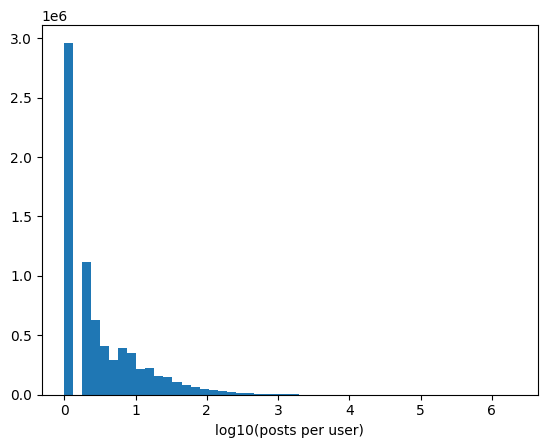

In [14]:
import numpy as np
import matplotlib.pyplot as plt

log_freq = np.log10(df["num_utterances_by_speaker"].clip(lower=1))
plt.hist(log_freq, bins=50)
plt.xlabel("log10(posts per user)")
plt.show()

/Users/nickvick/Desktop/Thesis/ORFE-Thesis/src/visualization.py:107: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby([pd.Grouper(freq=freq), "frequency_bucket"], observed=False)[metrics]


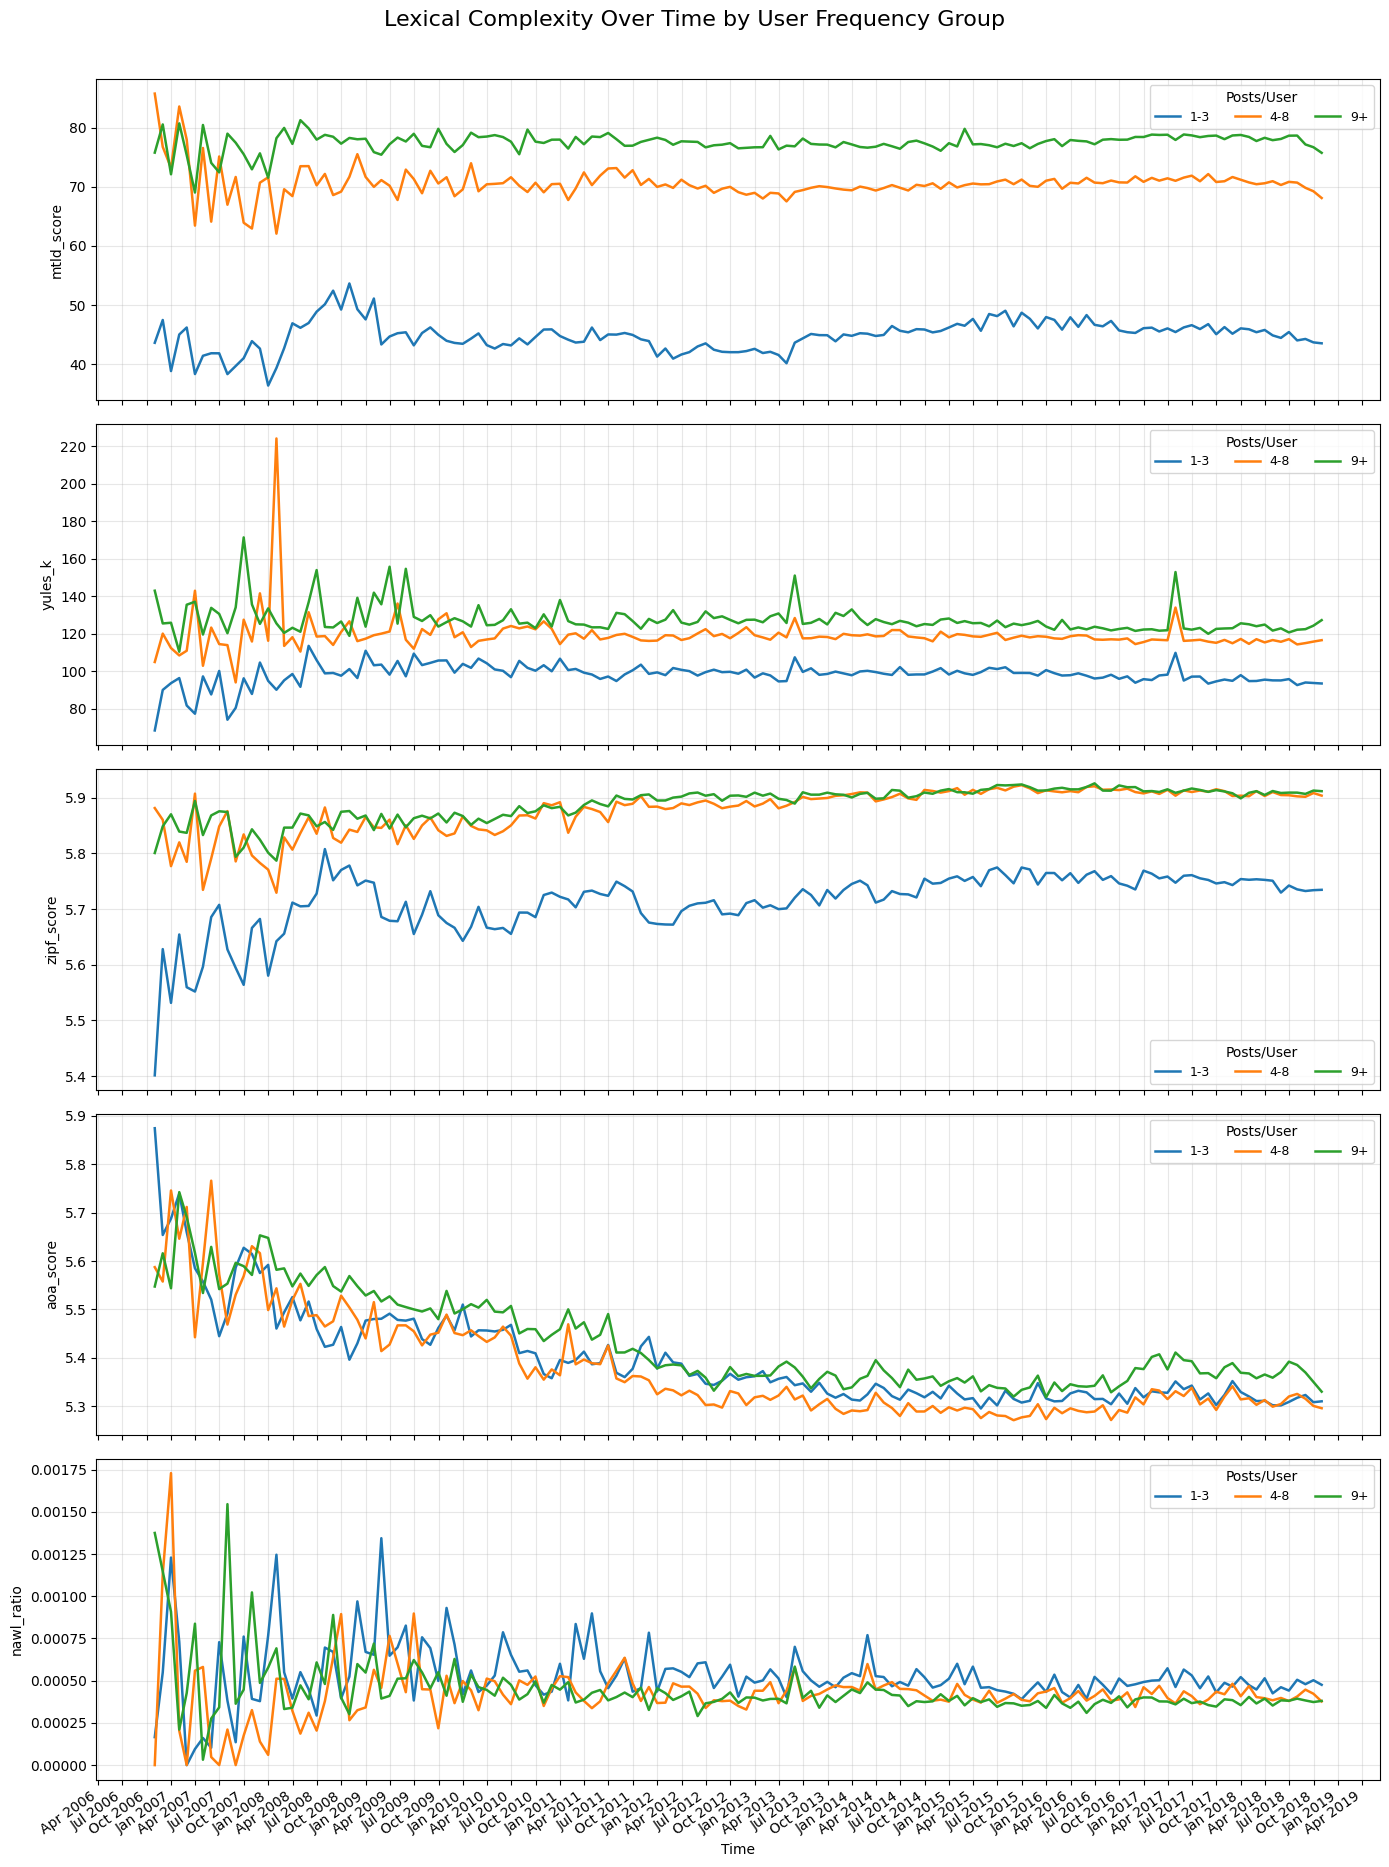

In [17]:
plot_complexity_by_user_frequency_over_time(df)

# Mann-Kendall Test

In [4]:
from data_analysis import run_mann_kendall_tests

# ── Overall trend (all subreddits combined, annual means) ──────────────────────
mk_overall = run_mann_kendall_tests(df, freq="Y")

print("=== Mann-Kendall Trend Tests — Full Dataset (annual means, 2007-2018) ===\n")
print(mk_overall[["metric", "n_periods", "tau", "sens_slope", "p_value", "p_adjusted", "significant", "trend"]].to_string(index=False))

# ── By source variation (Age / Topic / Culture) ────────────────────────────────
mk_by_variation = run_mann_kendall_tests(df, freq="Y", group_col="source_variation")

print("\n=== Mann-Kendall Trend Tests — By Variation Group (annual means) ===\n")
print(mk_by_variation[["group", "metric", "n_periods", "tau", "sens_slope", "p_value", "p_adjusted", "significant", "trend"]].to_string(index=False))

# ── By subreddit ────────────────────────────────────────────────────────────────
mk_by_sub = run_mann_kendall_tests(df, freq="Y", group_col="subreddit")

print("\n=== Mann-Kendall Trend Tests — By Subreddit (annual means) ===\n")
print(mk_by_sub[["group", "metric", "n_periods", "tau", "sens_slope", "p_value", "p_adjusted", "significant", "trend"]].to_string(index=False))

/Users/nickvick/Desktop/Thesis/ORFE-Thesis/src/data_analysis.py:387: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  resampled = grp_df[list(metrics)].resample(freq).mean().dropna(how="all")


=== Mann-Kendall Trend Tests — Full Dataset (annual means, 2007-2018) ===

    metric  n_periods     tau  sens_slope  p_value  p_adjusted  significant      trend
mtld_score         13  0.0769    0.143444 0.760332    0.760332        False   no trend
   yules_k         13 -0.1026   -0.406963 0.669334    0.760332        False   no trend
zipf_score         13  0.6923    0.008543 0.001223    0.003057         True increasing
 aoa_score         13 -0.8205   -0.024436 0.000121    0.000606         True decreasing
nawl_ratio         13 -0.5128   -0.000011 0.017343    0.028906         True decreasing


/Users/nickvick/Desktop/Thesis/ORFE-Thesis/src/data_analysis.py:387: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  resampled = grp_df[list(metrics)].resample(freq).mean().dropna(how="all")
/Users/nickvick/Desktop/Thesis/ORFE-Thesis/src/data_analysis.py:387: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  resampled = grp_df[list(metrics)].resample(freq).mean().dropna(how="all")
/Users/nickvick/Desktop/Thesis/ORFE-Thesis/src/data_analysis.py:387: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  resampled = grp_df[list(metrics)].resample(freq).mean().dropna(how="all")



=== Mann-Kendall Trend Tests — By Variation Group (annual means) ===

  group     metric  n_periods     tau  sens_slope  p_value  p_adjusted  significant      trend
    age mtld_score         11 -0.2727   -1.352046 0.275758    0.376033        False   no trend
    age    yules_k         11  0.2727    1.513378 0.275758    0.376033        False   no trend
    age zipf_score         11 -0.3091   -0.014193 0.212912    0.376033        False   no trend
    age  aoa_score         11 -0.0182   -0.005492 1.000000    1.000000        False   no trend
    age nawl_ratio         11  0.2545    0.000040 0.306079    0.382598        False   no trend
culture mtld_score         11 -0.2727   -0.649753 0.275758    0.376033        False   no trend
culture    yules_k         11 -0.4545   -0.689747 0.061707    0.132229        False   no trend
culture zipf_score         11  0.0909    0.000901 0.755497    0.809461        False   no trend
culture  aoa_score         11 -0.6364   -0.005876 0.008123    0.040617    

/Users/nickvick/Desktop/Thesis/ORFE-Thesis/src/data_analysis.py:387: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  resampled = grp_df[list(metrics)].resample(freq).mean().dropna(how="all")
/Users/nickvick/Desktop/Thesis/ORFE-Thesis/src/data_analysis.py:387: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  resampled = grp_df[list(metrics)].resample(freq).mean().dropna(how="all")
/Users/nickvick/Desktop/Thesis/ORFE-Thesis/src/data_analysis.py:387: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  resampled = grp_df[list(metrics)].resample(freq).mean().dropna(how="all")
/Users/nickvick/Desktop/Thesis/ORFE-Thesis/src/data_analysis.py:387: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  resampled = grp_df[list(metrics)].resample(freq).mean().dropna(how="all")
/Users/nickvick/Desktop/


=== Mann-Kendall Trend Tests — By Subreddit (annual means) ===

        group     metric  n_periods     tau  sens_slope  p_value  p_adjusted  significant      trend
        books mtld_score         11 -0.5273   -0.906341 0.029273    0.130186        False   no trend
        books    yules_k         11 -0.3091   -0.307071 0.212912    0.330381        False   no trend
        books zipf_score         11  0.5273    0.005229 0.029273    0.130186        False   no trend
        books  aoa_score         11 -0.4909   -0.009196 0.042960    0.148708        False   no trend
        books nawl_ratio         11  0.1636    0.000005 0.533417    0.648750        False   no trend
      college mtld_score         10  0.5556    1.437059 0.031823    0.130186        False   no trend
      college    yules_k         10  0.4222    1.167900 0.107405    0.230919        False   no trend
      college zipf_score         10  0.6444    0.015528 0.012266    0.091995        False   no trend
      college  aoa_score  